#  Customer Churn Analysis
**Tools:** Python · SQL · Power BI · Machine Learning

---

##  Stakeholder Objective
**Role:** Director of Customer Retention — Telecommunications Company

> *"We are losing customers and need to understand why. I need to identify which customer profiles have the highest probability of leaving, what factors are most associated with churn, and what concrete actions we can take to retain them before they leave. Every customer we lose represents revenue that doesn't come back."*

---

##  Business Questions
1. What customers have the highest probability of churning?
2. What combination of factors maximizes churn risk?
3. Does payment method have a relationship with churn?
4. Does churn relate to gender or senior citizens?
5. Do customers who pay more have a higher churn probability?
6. Does paperless billing relate to churn?
7. Do contracted services impact churn?
8. Do customers with more tenure have lower churn rates?
9. What is the estimated cost of churn in lost revenue?
10. What is the risk segmentation per customer to prioritize retention?

##  Section 1: Data Loading & Exploration

### 1.1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 1.2 Load Dataset

In [3]:
df_churn = pd.read_csv("https://raw.githubusercontent.com/FacundoMazzieri24/Facundomazzieri-portafolio/main/junior-level/customer-churn-analysis/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.3 Initial Exploration
We review the dataset size, data types, and a statistical summary to understand the data we are working with.

In [4]:
print("Shape:", df_churn.shape)
print(df_churn.info())
print(df_churn.describe())

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

##  Section 2: Data Cleaning

### 2.1 Remove Duplicates

In [5]:
df_churn = df_churn.drop_duplicates()
print("Duplicates after cleaning:", df_churn.duplicated().sum())

Duplicates after cleaning: 0


### 2.2 Check Null Values

In [6]:
df_churn.isnull().mean() * 100

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

### 2.3 Fix TotalCharges Column
`TotalCharges` is stored as `object` (string) instead of numeric. This occurs because some rows contain an empty space `" "` instead of a numeric value. These spaces are converted to nulls and then cast to numeric type.

In [7]:
df_churn['TotalCharges'] = df_churn['TotalCharges'].replace(" ", np.nan)
df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'])
print("Nulls in TotalCharges:", df_churn['TotalCharges'].isnull().sum())

Nulls in TotalCharges: 11


### 2.4 Inspect Null Records

In [8]:
df_churn[df_churn['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


### 2.5 Impute Nulls with 0
The 11 null records correspond to customers with `tenure = 0` — new customers who have not yet accumulated any charges. They are imputed with 0 as it is the logically correct value. They are not removed because they are real customers.

In [9]:
df_churn['TotalCharges'] = df_churn['TotalCharges'].fillna(0)
print("Nulls after imputation:", df_churn['TotalCharges'].isnull().sum())

Nulls after imputation: 0


### 2.6 Encode Churn Column
We encode the `Churn` column from text to numeric to use it in calculations and in the Machine Learning model:
- `No` → 0 (customer stayed)
- `Yes` → 1 (customer churned)

In [10]:
df_churn['Churn'] = df_churn['Churn'].map({'Yes': 1, 'No': 0})

### 2.7 Final Validation
We verify that the dataset is completely clean before continuing.

In [11]:
print("Shape:", df_churn.shape)
print("Nulls:", df_churn.isnull().sum().sum())
print("Duplicates:", df_churn.duplicated().sum())
print(df_churn.dtypes)

Shape: (7043, 21)
Nulls: 0
Duplicates: 0
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


### 2.8 Save Clean Dataset
We save the clean dataset as CSV to import into PostgreSQL in Phase 2 (SQL Analysis).

In [12]:
df_churn.to_csv("churn_clean.csv", index=False)
print("Clean dataset saved!")

Clean dataset saved!


##  Section 3: Exploratory Data Analysis (EDA)

In [13]:
churn_rate = df_churn['Churn'].mean() * 100
print(f"Churn rate: {churn_rate:.2f}%")

Churn rate: 26.54%


In [14]:
print(df_churn['Churn'].value_counts())
print(df_churn['Churn'].value_counts(normalize=True) * 100)

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


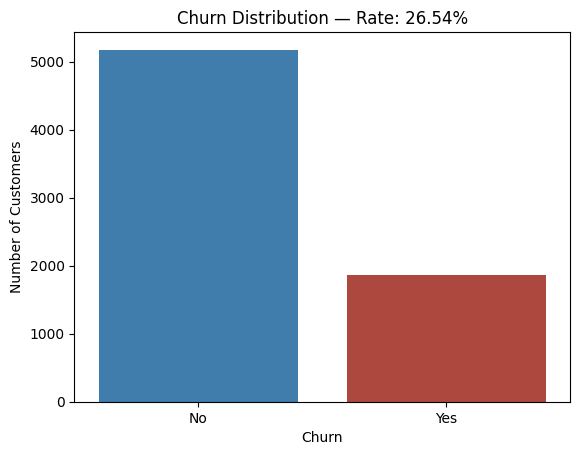

In [15]:
sns.countplot(x='Churn', data=df_churn, palette=['#2E7FBF', '#C0392B'])

plt.xticks([0, 1], ['No', 'Yes'])
plt.title(f"Churn Distribution — Rate: {churn_rate:.2f}%")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Insight
26.54% of customers churned, representing 1,869 lost customers out of 7,043. This is a significant rate that justifies a deep analysis to identify the risk factors.

### 3.2 Churn by Tenure and Contract Type

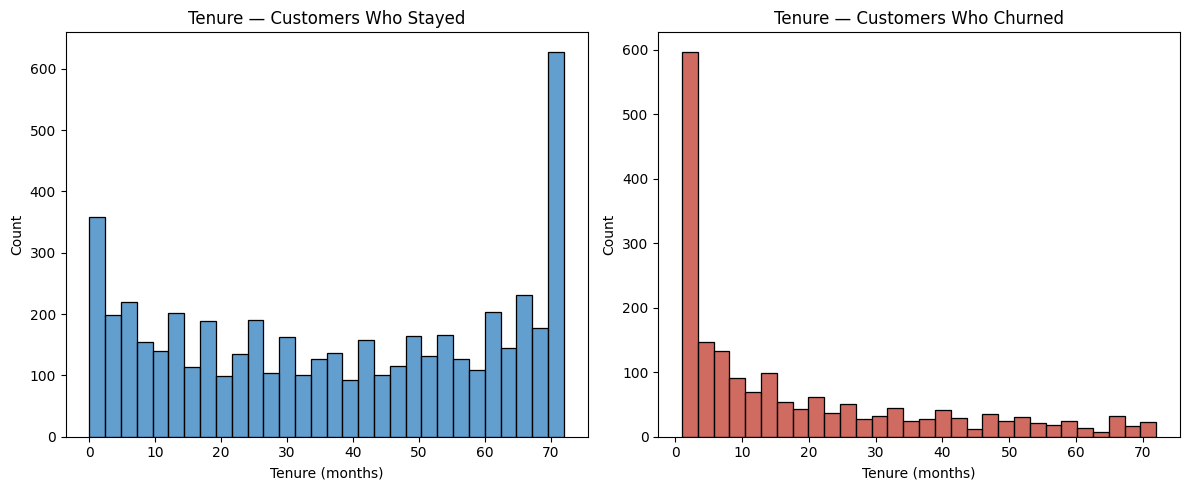

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df_churn[df_churn['Churn']==0], x='tenure', 
             bins=30, color='#2E7FBF', label='Se quedó', ax=axes[0])
axes[0].set_title("Tenure — Customers Who Stayed")
axes[0].set_xlabel("Tenure (months)")

sns.histplot(data=df_churn[df_churn['Churn']==1], x='tenure', 
             bins=30, color='#C0392B', label='Se fue', ax=axes[1])
axes[1].set_title("Tenure — Customers Who Churned")
axes[1].set_xlabel("Tenure (months)")

plt.tight_layout()
plt.show()

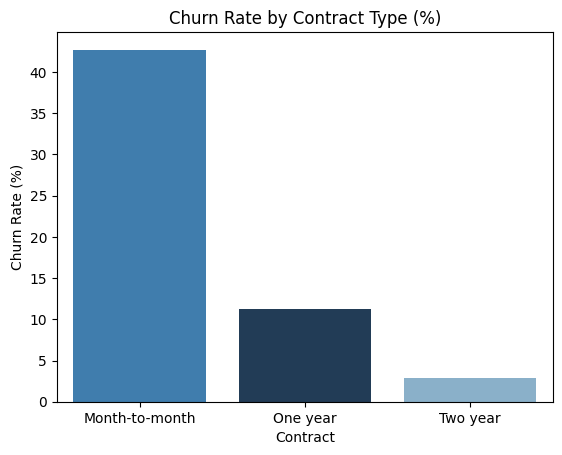

In [17]:
churn_by_contract = df_churn.groupby('Contract')['Churn'].mean().reset_index()
churn_by_contract['Churn'] = churn_by_contract['Churn'] * 100

sns.barplot(data=churn_by_contract, x='Contract', y='Churn', palette=['#2E7FBF', '#1A3C5E', '#7FB3D3'])

plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight
Month-to-month customers show the highest churn rate (~43%), while one-year (~11%) and two-year (~3%) contracts show significantly lower rates.

The histogram confirms that most churned customers have low tenure — the first months are the critical retention window. Strategy should focus on retaining customers during the first 12 months.

### 3.3 Does Payment Method Relate to Churn?

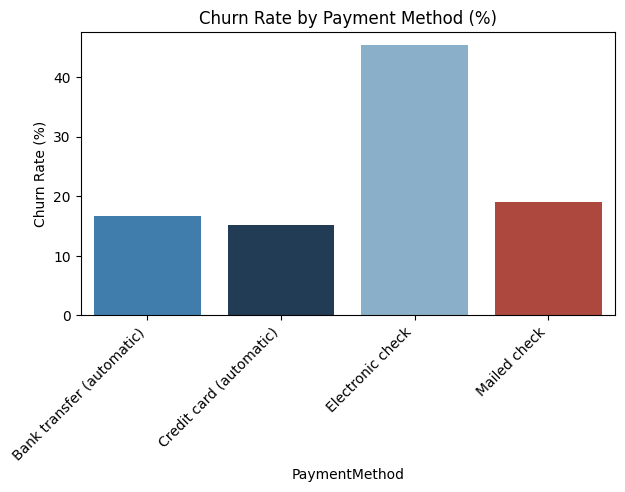

In [18]:
churn_by_PaymentMethod = df_churn.groupby('PaymentMethod')['Churn'].mean().reset_index()
churn_by_PaymentMethod['Churn'] = churn_by_PaymentMethod['Churn'] * 100

sns.barplot(data=churn_by_PaymentMethod, x='PaymentMethod', y='Churn', palette=['#2E7FBF', '#1A3C5E', '#7FB3D3', '#C0392B'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.title("Churn Rate by Payment Method (%)")
plt.ylabel("Churn Rate (%)")

plt.show()

In [19]:
print(churn_by_PaymentMethod)

               PaymentMethod      Churn
0  Bank transfer (automatic)  16.709845
1    Credit card (automatic)  15.243101
2           Electronic check  45.285412
3               Mailed check  19.106700


### Insight
**Electronic Check** shows the highest churn rate (~45%), well above other methods which range between 15-19%.

Automatic payment methods (Bank Transfer and Credit Card) have the lowest rates, suggesting that payment automation increases retention — the customer does not need to take an active action to pay, reducing cancellation friction.

**Recommendation:** Investigate UX friction points in the Electronic Check experience before making changes.

### 3.4 Does Churn Relate to Gender or Senior Citizens?


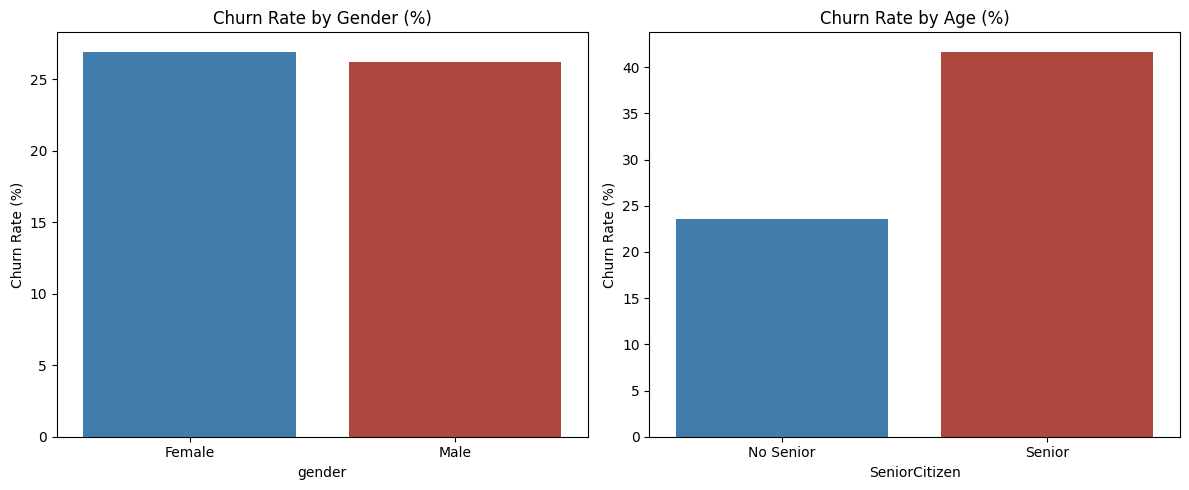

In [20]:
# Calculate churn by gender
churn_by_gender = df_churn.groupby('gender')['Churn'].mean().reset_index()
churn_by_gender['Churn'] = churn_by_gender['Churn'] * 100

# Calculate churn by Senior Citizen
churn_by_senior = df_churn.groupby('SeniorCitizen')['Churn'].mean().reset_index()
churn_by_senior['Churn'] = churn_by_senior['Churn'] * 100
churn_by_senior['SeniorCitizen'] = churn_by_senior['SeniorCitizen'].map({0: 'No Senior', 1: 'Senior'})

# Side by side charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=churn_by_gender, x='gender', y='Churn', 
            palette=['#2E7FBF', '#C0392B'], ax=axes[0])
axes[0].set_title("Churn Rate by Gender (%)")
axes[0].set_ylabel("Churn Rate (%)")

sns.barplot(data=churn_by_senior, x='SeniorCitizen', y='Churn', 
            palette=['#2E7FBF', '#C0392B'], ax=axes[1])
axes[1].set_title("Churn Rate by Age (%)")
axes[1].set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [21]:
print(churn_by_gender)
print(churn_by_senior)

   gender      Churn
0  Female  26.920872
1    Male  26.160338
  SeniorCitizen      Churn
0     No Senior  23.606168
1        Senior  41.681261


### Insight
**Gender:** Churn rate is practically equal between males (26.16%) and females (26.90%) — gender is not a determining churn factor.

**Age:** Senior customers churn at 41.68% vs 23.60% for non-seniors — nearly double. This suggests seniors are a high-risk segment requiring specific retention strategies, possibly related to economic or technical support factors.

**Recommendation:** Design special plans for Senior customers — discounts, priority support, or annual contracts with benefits.

### 3.5 Do Customers Who Pay More Have Higher Churn Probability?

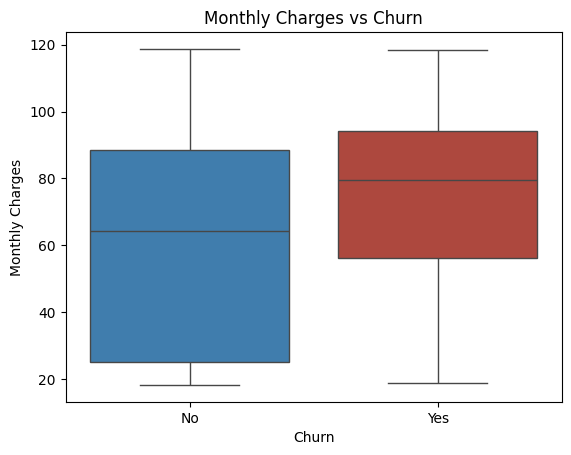

In [22]:
sns.boxplot(data=df_churn, x='Churn', y='MonthlyCharges', palette=['#2E7FBF', '#C0392B'])

plt.xticks([0, 1], ['No', 'Yes'])
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [23]:
print(df_churn.groupby('Churn')['MonthlyCharges'].mean())

Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64


### Insight
Churned customers paid on average **$74.44/month** vs **$61.26/month** for those who stayed — a difference of ~$13 per month.

This suggests that customers with higher charges are more price-sensitive and more likely to look for cheaper alternatives.

**Recommendation:** Review the pricing structure for high-consumption customers and evaluate loyalty discounts before they reach the churn point.

### 3.6 Does Paperless Billing Relate to Churn?

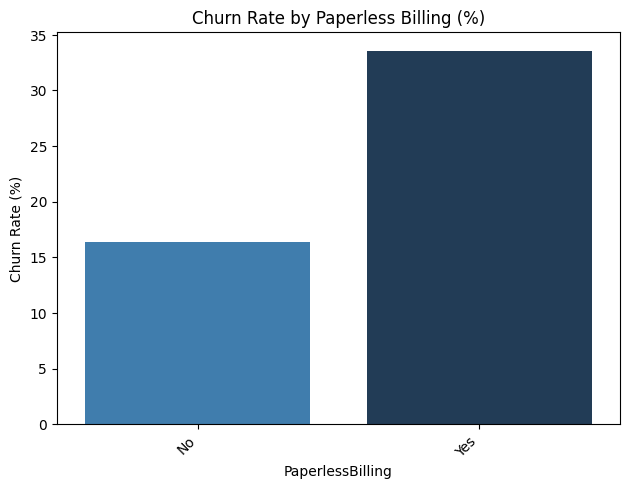

In [24]:
churn_by_PaperlessBilling = df_churn.groupby('PaperlessBilling')['Churn'].mean().reset_index()
churn_by_PaperlessBilling['Churn'] = churn_by_PaperlessBilling['Churn'] * 100

sns.barplot(data=churn_by_PaperlessBilling, x='PaperlessBilling', y='Churn', palette=['#2E7FBF', '#1A3C5E'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.title("Churn Rate by Paperless Billing (%)")
plt.ylabel("Churn Rate (%)")

plt.show()

In [25]:
print(churn_by_PaperlessBilling)

  PaperlessBilling      Churn
0               No  16.330084
1              Yes  33.565092


### 3.7 Do Contracted Services Impact Churn?

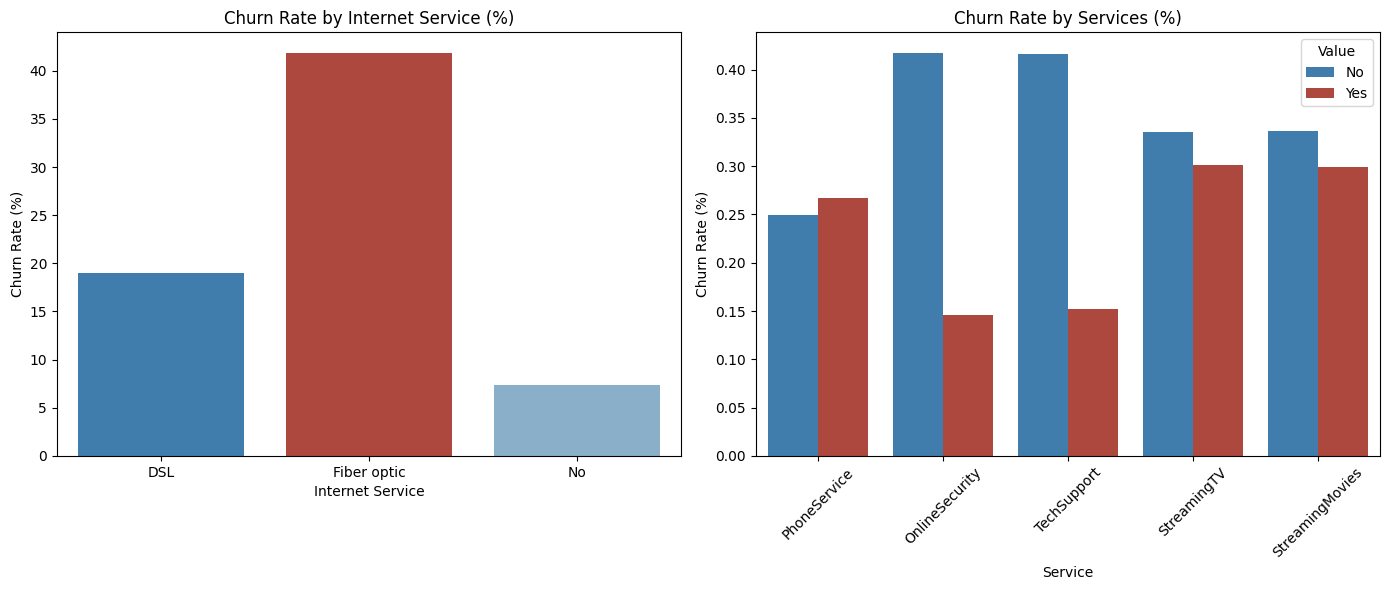

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Internet Service separately
churn_internet = df_churn.groupby('InternetService')['Churn'].mean().reset_index()
churn_internet['Churn'] = churn_internet['Churn'] * 100
sns.barplot(data=churn_internet, x='InternetService', y='Churn',
            palette=['#2E7FBF', '#C0392B', '#7FB3D3'], ax=axes[0])
axes[0].set_title("Churn Rate by Internet Service (%)")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_xlabel("Internet Service")

# Chart 2 — Binary services Yes/No
services_binary = ['PhoneService', 'OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies']
results = []

for service in services_binary:
    churn_rate = df_churn[df_churn[service] != 'No internet service'].groupby(service)['Churn'].mean().reset_index()
    churn_rate.columns = ['Value', 'Churn']
    churn_rate['Service'] = service
    results.append(churn_rate)

df_binary = pd.concat(results)
sns.barplot(data=df_binary, x='Service', y='Churn', hue='Value',
            palette=['#2E7FBF', '#C0392B'], ax=axes[1])
axes[1].set_title("Churn Rate by Services (%)")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [27]:
print(churn_internet)

  InternetService      Churn
0             DSL  18.959108
1     Fiber optic  41.892765
2              No   7.404980


In [28]:
print(df_binary.pivot(index='Service', columns='Value', values='Churn').round(4) * 100)

Value               No    Yes
Service                      
OnlineSecurity   41.77  14.61
PhoneService     24.93  26.71
StreamingMovies  33.68  29.94
StreamingTV      33.52  30.07
TechSupport      41.64  15.17


### Insight
**OnlineSecurity and TechSupport** are the most relevant services for retention — customers without these services have nearly triple the churn (~41%) vs those who have them (~15%).

**PhoneService** shows no significant difference between having it or not (~25% vs ~27%).

**Recommendation:** Promote OnlineSecurity and TechSupport during onboarding to increase customer stickiness.

### 3.8 Do Customers with More Tenure Have Lower Churn Rates?


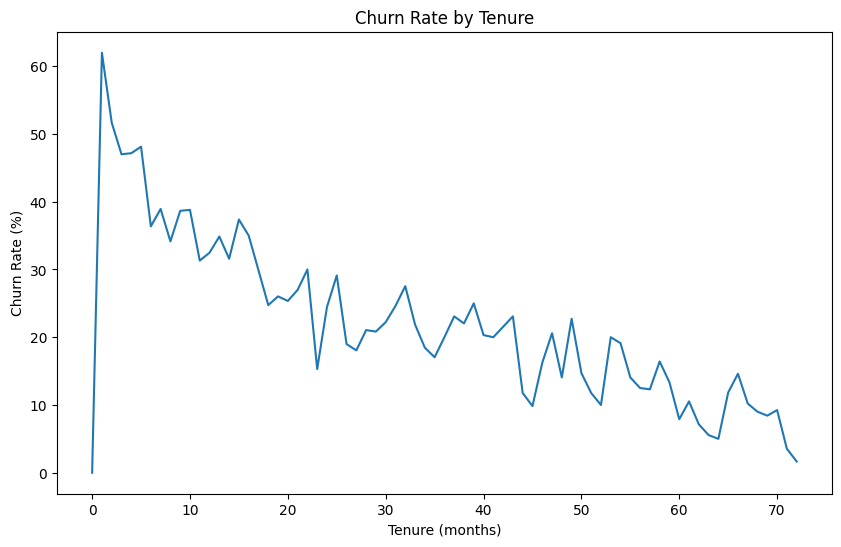

In [29]:
# Calculate churn rate by tenure
churn_by_tenure = df_churn.groupby('tenure')['Churn'].mean() * 100

# Line chart
plt.figure(figsize=(10,6))
plt.plot(churn_by_tenure.index, churn_by_tenure.values)

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Churn Rate (%)")

plt.show()

In [30]:
print(churn_by_tenure)

tenure
0      0.000000
1     61.990212
2     51.680672
3     47.000000
4     47.159091
        ...    
68     9.000000
69     8.421053
70     9.243697
71     3.529412
72     1.657459
Name: Churn, Length: 73, dtype: float64


### 3.9 What is the Estimated Revenue Lost by Churn?


In [31]:
churned_customers = df_churn[df_churn['Churn'] == 1].shape[0]
avg_monthly_charges = df_churn[df_churn['Churn'] == 1]['MonthlyCharges'].mean()
monthly_revenue_lost = churned_customers * avg_monthly_charges
annual_revenue_lost = monthly_revenue_lost * 12
print(f"Lost customers: {churned_customers}")
print(f"Average Monthly Charges: ${avg_monthly_charges:.2f}")
print(f"Monthly revenue lost: ${monthly_revenue_lost:,.2f}")
print(f"Annual revenue lost: ${annual_revenue_lost:,.2f}")

Lost customers: 1869
Average Monthly Charges: $74.44
Monthly revenue lost: $139,130.85
Annual revenue lost: $1,669,570.20


### Insight
Churn represents a significant economic loss for the company.

- **Lost customers:** 1,869
- **Average monthly charge:** $74.44
- **Monthly revenue lost:** $139,130.85
- **Annual revenue lost:** $1,669,570.20

Retaining even 20% of those customers would recover more than **$333,914 annually**. This strongly justifies investing in retention strategies such as discounts, priority support, or improvements in high-churn services.

### 3.10 What is the Risk Segmentation per Customer to Prioritize Retention?

In [32]:
def risk_segment(row):
    if row['Contract'] == 'Month-to-month' and row['tenure'] < 12:
        return 'High Risk'
    elif row['Contract'] == 'Month-to-month' and 12 <= row['tenure'] <= 24:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_churn['RiskLevel'] = df_churn.apply(risk_segment, axis=1)

In [33]:
print(df_churn['RiskLevel'].value_counts())
print(df_churn.groupby('RiskLevel')['Churn'].mean() * 100)

RiskLevel
Low Risk       4312
High Risk      1908
Medium Risk     823
Name: count, dtype: int64
RiskLevel
High Risk      51.939203
Low Risk       13.149351
Medium Risk    37.788578
Name: Churn, dtype: float64


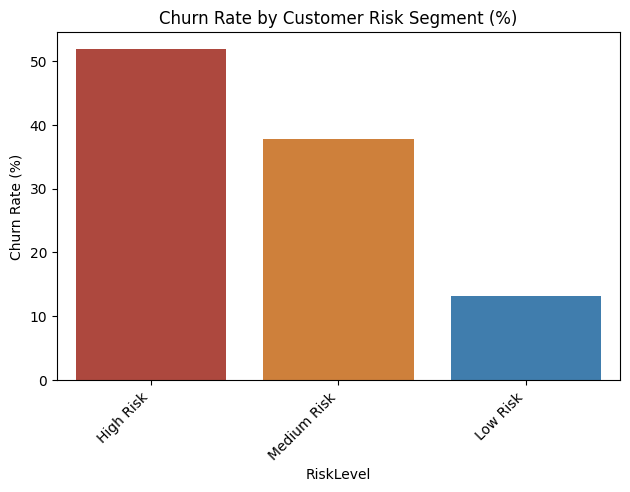

In [34]:
churn_by_RiskLevel = df_churn.groupby('RiskLevel')['Churn'].mean().reset_index()
churn_by_RiskLevel['Churn'] = churn_by_RiskLevel['Churn'] * 100
order = ['High Risk', 'Medium Risk', 'Low Risk']
sns.barplot(data=churn_by_RiskLevel, x='RiskLevel', y='Churn', 
            order=order,
            palette=['#C0392B', '#E67E22', '#2E7FBF'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.title("Churn Rate by Customer Risk Segment (%)")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight
The risk segmentation confirms the logic from the previous analysis:

- **High Risk** (month-to-month contract + less than 12 months tenure): 51.9% churn — 1,908 customers
- **Medium Risk** (month-to-month contract + 12 to 24 months): 37.8% churn — 823 customers
- **Low Risk** (annual/two-year contract or more than 24 months): 13.1% churn — 4,312 customers

**Recommendation:** Prioritize retention actions for the 1,908 High Risk customers — they have the highest churn rate and are the most impactable with incentives during the first 12 months.

##  Section 4: Machine Learning — Churn Prediction Model
The goal is to predict which customers have the highest probability of churning using a Logistic Regression model.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [36]:
# Select relevant features
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
            'Contract', 'PaymentMethod', 'InternetService', 
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

df_model = df_churn[features + ['Churn']].copy()

# Encode categorical columns to numeric
df_model = pd.get_dummies(df_model, drop_first=True)

print("Shape:", df_model.shape)
print(df_model.columns.tolist())

Shape: (7043, 17)
['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'PaperlessBilling_Yes']


In [37]:
print("df_churn shape:", df_churn.shape)
print("df_model shape:", df_model.shape)
print("df_churn columns:", df_churn.columns.tolist())

df_churn shape: (7043, 22)
df_model shape: (7043, 17)
df_churn columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'RiskLevel']


In [38]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5634, 16)
X_test: (1409, 16)


In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [41]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8626949910461974


### Insight — Logistic Regression Model
- **Accuracy:** 81% — the model correctly predicts 8 out of 10 cases
- **ROC-AUC:** 0.86 — excellent ability to separate at-risk customers
- **167 false negatives** — customers who churned but the model did not detect
- **99 false alarms** — customers who did not churn but the model flagged as risk

The most critical metric for the business is **Churn Recall (55%)** — the model detects just over half of at-risk customers. A future improved version would prioritize increasing this number to capture more customers before they leave.

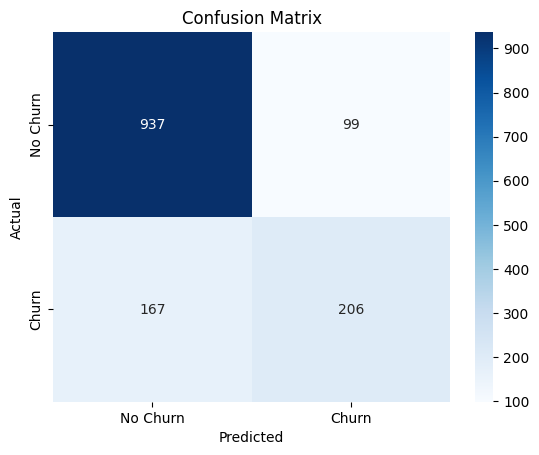

In [42]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

                                  Feature  Coefficient
0                                  tenure     1.326264
2                            TotalCharges     0.696227
5                       Contract_Two year     0.611056
9             InternetService_Fiber optic     0.270504
4                       Contract_One year     0.267110
12                     OnlineSecurity_Yes     0.228638
15                   PaperlessBilling_Yes     0.182170
14                        TechSupport_Yes     0.175855
7          PaymentMethod_Electronic check     0.174271
10                     InternetService_No     0.127938
13        TechSupport_No internet service     0.127938
11     OnlineSecurity_No internet service     0.127938
3                           SeniorCitizen     0.081184
1                          MonthlyCharges     0.072827
6   PaymentMethod_Credit card (automatic)     0.035241
8              PaymentMethod_Mailed check     0.025632


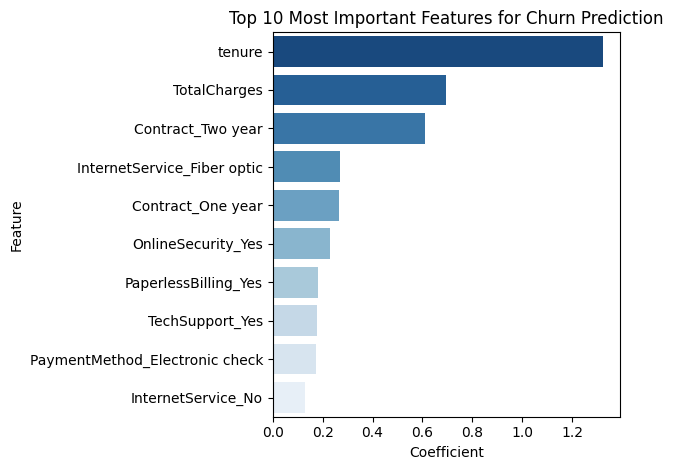

In [43]:
# Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': abs(model.coef_[0])
}).sort_values('Coefficient', ascending=False)

print(importance)

sns.barplot(data=importance.head(10), x='Coefficient', y='Feature', 
            palette='Blues_r')
plt.title("Top 10 Most Important Features for Churn Prediction")
plt.tight_layout()
plt.show()

### Final Insight — Most Important Features
The variables with the highest impact on churn confirm the EDA findings: tenure, TotalCharges, contract type and InternetService Fiber optic are the main predictors.

This suggests that the retention strategy should focus on the early months of a customer's lifecycle, especially those with month-to-month contracts and fiber optic internet service.